In [4]:
import json
import torch
from docling_core.types.doc import DoclingDocument
from docling_core.types.doc.document import DocTagsDocument
from transformers import AutoProcessor, AutoModelForVision2Seq
from transformers.image_utils import load_image
from pathlib import Path
from PIL import Image
import torch.multiprocessing as mp

import os
import re
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"

model_path = "/data/home/yunhao/.cache/huggingface/hub/models--ds4sd--SmolDocling-256M-preview/snapshots/ce51f56c4ebe36e0b1c3a55f67b261ba22a50bf8"

In [5]:
def strip_doctags(s: str) -> str:
    # 精准去除 SmolDocling 的 DocTags 标记（结构和位置标记）
    # 结构标记
    struct_tags = r"(doctag|text|title|paragraph|list|item|table|row|cell|figure|caption|code|formula|header|footer|page|column|section)"
    # 位置标记：loc_数字 或 bbox_数字_数字_数字_数字
    loc_tags = r"(loc_\d+|bbox_\d+_\d+_\d+_\d+)"
    # 组合正则：匹配 <tag> 形式
    pattern = rf"<({struct_tags}|{loc_tags})>"
    s = re.sub(pattern, "", s)
    # 合并空白
    s = re.sub(r"\s+", " ", s).strip()
    return s

def load_model(gpu_id=0):
    processor = AutoProcessor.from_pretrained(model_path)
    model = AutoModelForVision2Seq.from_pretrained(
    model_path,
    torch_dtype=torch.bfloat16,
    _attn_implementation="flash_attention_2",
    ).to("cuda:"+str(gpu_id))
    return processor, model

def load_data(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data

def load_image(image_path):
    return Image.open(image_path).convert("RGB")

In [6]:
processor, model = load_model()

图像大小: (900, 536)
schema_name='DoclingDocument' version='1.8.0' name='Document' origin=None furniture=GroupItem(self_ref='#/furniture', parent=None, children=[], content_layer=<ContentLayer.FURNITURE: 'furniture'>, meta=None, name='_root_', label=<GroupLabel.UNSPECIFIED: 'unspecified'>) body=GroupItem(self_ref='#/body', parent=None, children=[RefItem(cref='#/texts/0')], content_layer=<ContentLayer.BODY: 'body'>, meta=None, name='_root_', label=<GroupLabel.UNSPECIFIED: 'unspecified'>) groups=[] texts=[TextItem(self_ref='#/texts/0', parent=RefItem(cref='#/body'), children=[], content_layer=<ContentLayer.BODY: 'body'>, meta=None, label=<DocItemLabel.TEXT: 'text'>, prov=[ProvenanceItem(page_no=1, bbox=BoundingBox(l=19.799999999999997, t=23.584, r=876.6, b=527.424, coord_origin=<CoordOrigin.TOPLEFT: 'TOPLEFT'>), charspan=(0, 2328))], orig='EYuoV qUtjpy pWxZCks vUQnhw K qCuYCXmor x FTMKWoE ktFUxJGS BX CoYO eyEZI HGUPXY iYw VuTIFKKYY p JBvr qlqxkmNkLYfCmnx PRCTv vldGtGU YbAHYff yWyBsP pdiHfPeL
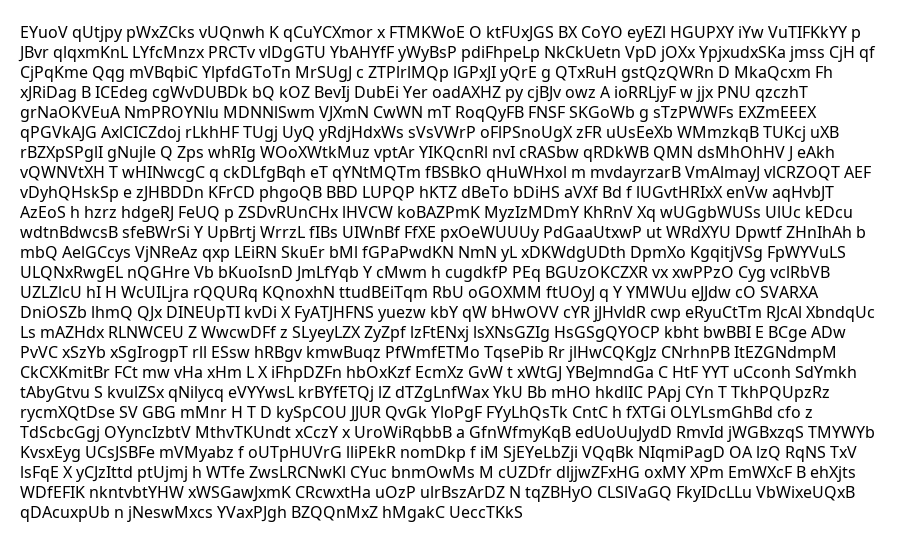
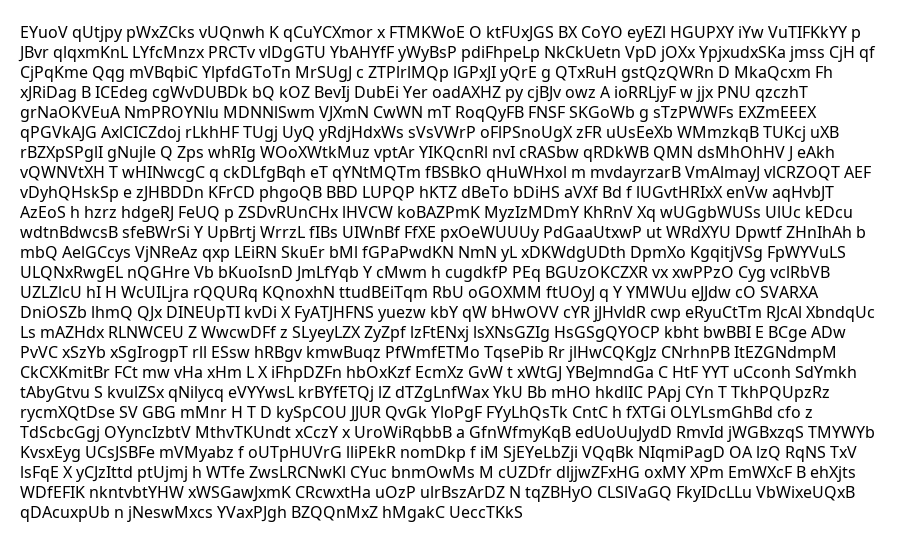

In [13]:
device = "cuda:0"
image_path = "/data/home/yunhao/code/ocr/fox_data/random/random_2.png"
image = load_image(image_path)
# 手动缩放图像以适应模型（避免 resolution_max_side 错误）
max_side = 1536  # 根据模型配置调整
w, h = image.size
scale = min(1.0, max_side / max(w, h))
if scale < 1.0:
    image = image.resize((int(w * scale), int(h * scale)), Image.LANCZOS)
print(f"图像大小: {image.size}")
# Create input messages
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": "Convert this page to docling."}
        ]
    },
]
# Prepare inputs
prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
inputs = processor(text=prompt, images=[image], return_tensors="pt", do_resize=True)
inputs = inputs.to(device)

# Generate outputs
generated_ids = model.generate(**inputs, max_new_tokens=8192)
prompt_length = inputs.input_ids.shape[1]
trimmed_generated_ids = generated_ids[:, prompt_length:]
doctags = processor.batch_decode(
    trimmed_generated_ids,
    skip_special_tokens=False,
)[0].lstrip()

# Populate document
doctags_doc = DocTagsDocument.from_doctags_and_image_pairs([doctags], [image])
# print(doctags)
# create a docling document
doc = DoclingDocument.load_from_doctags(doctags_doc, document_name="Document")
print(doc)

In [23]:
print(doctags_doc)

pages=[DocTagsPage(tokens='<doctag><text><loc_1><loc_499><loc_10><loc_499>Powered by TCPDF (www.tcpdf.org)</text>\n<text><loc_1><loc_13><loc_499><loc_499>RpWLHWG KLFBjoBfTuHXhY BAHNK RqYZIyWL rasp okWrPm wmhdAiGq gZr1yYyZwbDzfIXkTCypUw ASY0NXaL0 yhHQdK5xXTcYLkTQ m0LbAjoRyBifJeJafHMbGeHTO0bKYnhGcKKhNbZGpIyLQZdTqYLJmGmUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUU

In [14]:
import re

def markdown_to_text(md: str) -> str:
    # 去除 Markdown 标记，提取纯文本
    # 去除代码块
    md = re.sub(r'```.*?```', '', md, flags=re.DOTALL)
    # 去除内联代码
    md = re.sub(r'`([^`]*)`', r'\1', md)
    # 去除链接 [text](url)
    md = re.sub(r'\[([^\]]*)\]\([^)]*\)', r'\1', md)
    # 去除图片 ![alt](url)
    md = re.sub(r'!\[([^\]]*)\]\([^)]*\)', '', md)
    # 去除粗体/斜体 **text** 或 *text*
    md = re.sub(r'\*\*([^\*]*)\*\*', r'\1', md)
    md = re.sub(r'\*([^\*]*)\*', r'\1', md)
    # 去除标题 # 
    md = re.sub(r'^#+\s*', '', md, flags=re.MULTILINE)
    # 去除列表标记 - 或数字.
    md = re.sub(r'^[-\d]+\.\s*', '', md, flags=re.MULTILINE)
    # 合并空白
    md = re.sub(r'\s+', ' ', md).strip()
    return md

# 获取 Markdown
md = doc.export_to_markdown()
print("Markdown:")
print(md)
print("\n提取的纯文本:")
plain_text = markdown_to_text(md)
print(plain_text)

Markdown:
EYuoV qUtjpy pWxZCks vUQnhw K qCuYCXmor x FTMKWoE ktFUxJGS BX CoYO eyEZI HGUPXY iYw VuTIFKKYY p JBvr qlqxkmNkLYfCmnx PRCTv vldGtGU YbAHYff yWyBsP pdiHfPeLp NkCkUetn VpD jOXx YpjuxdxSkA jmss CjH qf CjPqKme Qqg mVBqbiC YlpfdGToTn MrSugl c ZTPlIrMQp IGPxJI yQrE g QTxRuH gstQzQWRn D MkaQcxm Fh xJiRdA KIcEG cgWvDUBdk bQ kOZ Bevj DubEi Yer oadAXHZ py cjBjv owz Aio iORRljyF w jjx PNU qzczhT grrNaOKVEuA NmPROYNlu MDNNSw VJxmN CwWn mT RoqQyFB FNSF SKGowb g sTZPWWFs EXZmEEEX qPGVkVAG AXlCICZdoj rLkhHF Tugj UyQ yRdjHdxWs sVsWrP oFPSnoUgXzFR uSeEExb WMmzkqB TUkcj uXB rBZXSpGLi gNuJle Q Zps whRig WOoXWtkMuv vptAr YlKcqnRl nvI cRASbw qRDkWB QMN dsMhOhHV J eAkh vQWNVtXH T wHInNwcq ckDLfqBgh et qYNtMQTm fBSkBko qHuWhXhol m mvdayrzarB VmAlmayvlCRZOQT AEF vDyhQhSkSp e zJHBDDn KFrCD phgoQB BBD LUPQP hKTZ dBeTo bDiHS aVXfBd f IUGtvHRlXx enVw aqHvbJT AzEoS h hzrz hdgeRJ FeUQ p ZSDvRUnChx IHVCW koBAZPmK MyzIzMDmY KhnRnV Xq wUGgbWUSs UIuc kEDcu wdtnBdwcsB sfEBWrSi Y UpBtrj WrrzL fiBS UIWnB FfXE pxO

原始 doctags 字符串:
'<doctag><text><loc_7><loc_11><loc_492><loc_498>EyuQ vQ tijpy pWxZCs vUQnhM k QcuYcXMor x FTMKWO e O kTfuXjG BS X BO cO yEiZ HGUPY iY wvuTIFKKY y PbD qrqxamnKL NfcycMx PnCTV dGdG YbHHYfY ybWyBdP pPdIhPeL NkCkUen VpD JoJX xPjyudxKa sJmCg JQh f qjqQqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqq
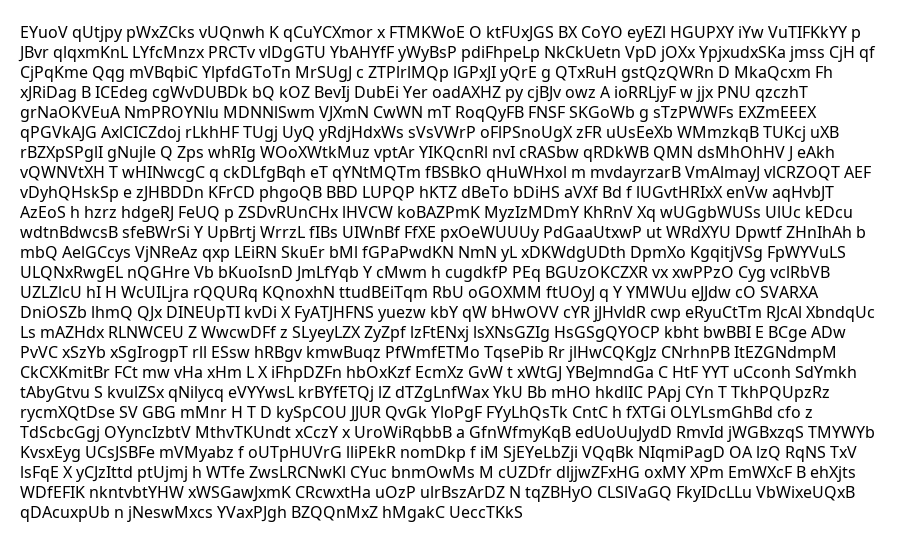

In [12]:
# 调试 doctags 和文档解析
print("原始 doctags 字符串:")
print(repr(doctags))
print(f"doctags 是否为空: {not doctags}")
print("\nDocTagsDocument 解析结果:")
print(doctags_doc)
print(f"doc.pages 类型: {type(doc.pages)}")
print(f"doc.pages: {doc.pages}")
try:
    if doc.pages:
        print(f"第一页元素数: {len(doc.pages[0].elements)}")
        for i, el in enumerate(doc.pages[0].elements[:3]):  # 前3个元素
            print(f"元素 {i}: {type(el).__name__} - text: {getattr(el, 'text', '无 text 属性')}")
    else:
        print("doc.pages 为空，无法提取元素")
except Exception as e:
    print(f"访问 doc.pages[0] 出错: {e}")
print(f"export_to_markdown() 结果: '{doc.export_to_markdown()}'")

# 如果 doctags 为空，检查模型生成
if not doctags:
    print("\n警告: doctags 为空，可能模型生成失败。检查图像路径、模型加载或 GPU 可用性。")
    print(f"图像路径: {image_path}")
    print(f"图像大小: {image.size if 'image' in locals() else '未加载'}")